In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [4]:

df = pd.read_csv('all_stocks_5yr.csv')
df['date'] = pd.to_datetime(df['date'])

print("THÔNG TIN DỮ LIỆU")
print("="*60)
print(f"Số dòng: {len(df):,}")
print(f"Số cột: {len(df.columns)}")
print(f"Khoảng thời gian: {df['date'].min()} → {df['date'].max()}")
print(f"Số cổ phiếu: {df['Name'].nunique()}")
print(f"\nCác cột: {df.columns.tolist()}")
print("\n5 dòng đầu tiên:")
print(df.head())

# Danh sách tất cả cổ phiếu
all_stocks = df['Name'].unique()
print(f"\n Danh sách {len(all_stocks)} cổ phiếu:")
print(all_stocks[:20])  

THÔNG TIN DỮ LIỆU
Số dòng: 619,040
Số cột: 7
Khoảng thời gian: 2013-02-08 00:00:00 → 2018-02-07 00:00:00
Số cổ phiếu: 505

Các cột: ['date', 'open', 'high', 'low', 'close', 'volume', 'Name']

5 dòng đầu tiên:
        date    open    high     low   close    volume Name
0 2013-02-08 15.0700 15.1200 14.6300 14.7500   8407500  AAL
1 2013-02-11 14.8900 15.0100 14.2600 14.4600   8882000  AAL
2 2013-02-12 14.4500 14.5100 14.1000 14.2700   8126000  AAL
3 2013-02-13 14.3000 14.9400 14.2500 14.6600  10259500  AAL
4 2013-02-14 14.9400 14.9600 13.1600 13.9900  31879900  AAL

 Danh sách 505 cổ phiếu:
['AAL' 'AAPL' 'AAP' 'ABBV' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM' 'ADP'
 'ADSK' 'ADS' 'AEE' 'AEP' 'AES' 'AET' 'AFL' 'AGN' 'AIG']


 GIÁ ĐÓNG CỬA 7 CỔ PHIẾU CÔNG NGHỆ
Số ngày: 1259
Từ: 2013-02-08 00:00:00 → 2018-02-07 00:00:00

5 ngày đầu tiên:
Name          AAPL    ADBE     AMZN    GOOGL    MSFT    NVDA
date                                                        
2013-02-08 67.8542 39.1200 261.9500 393.0777 27.5500 12.3700
2013-02-11 68.5614 38.6400 257.2100 391.6012 27.8600 12.5100
2013-02-12 66.8428 38.8900 258.7000 390.7403 27.8800 12.4300
2013-02-13 66.7156 38.8100 269.4700 391.8214 28.0300 12.3700
2013-02-14 66.6556 38.6100 269.2400 394.3039 28.0400 12.7300


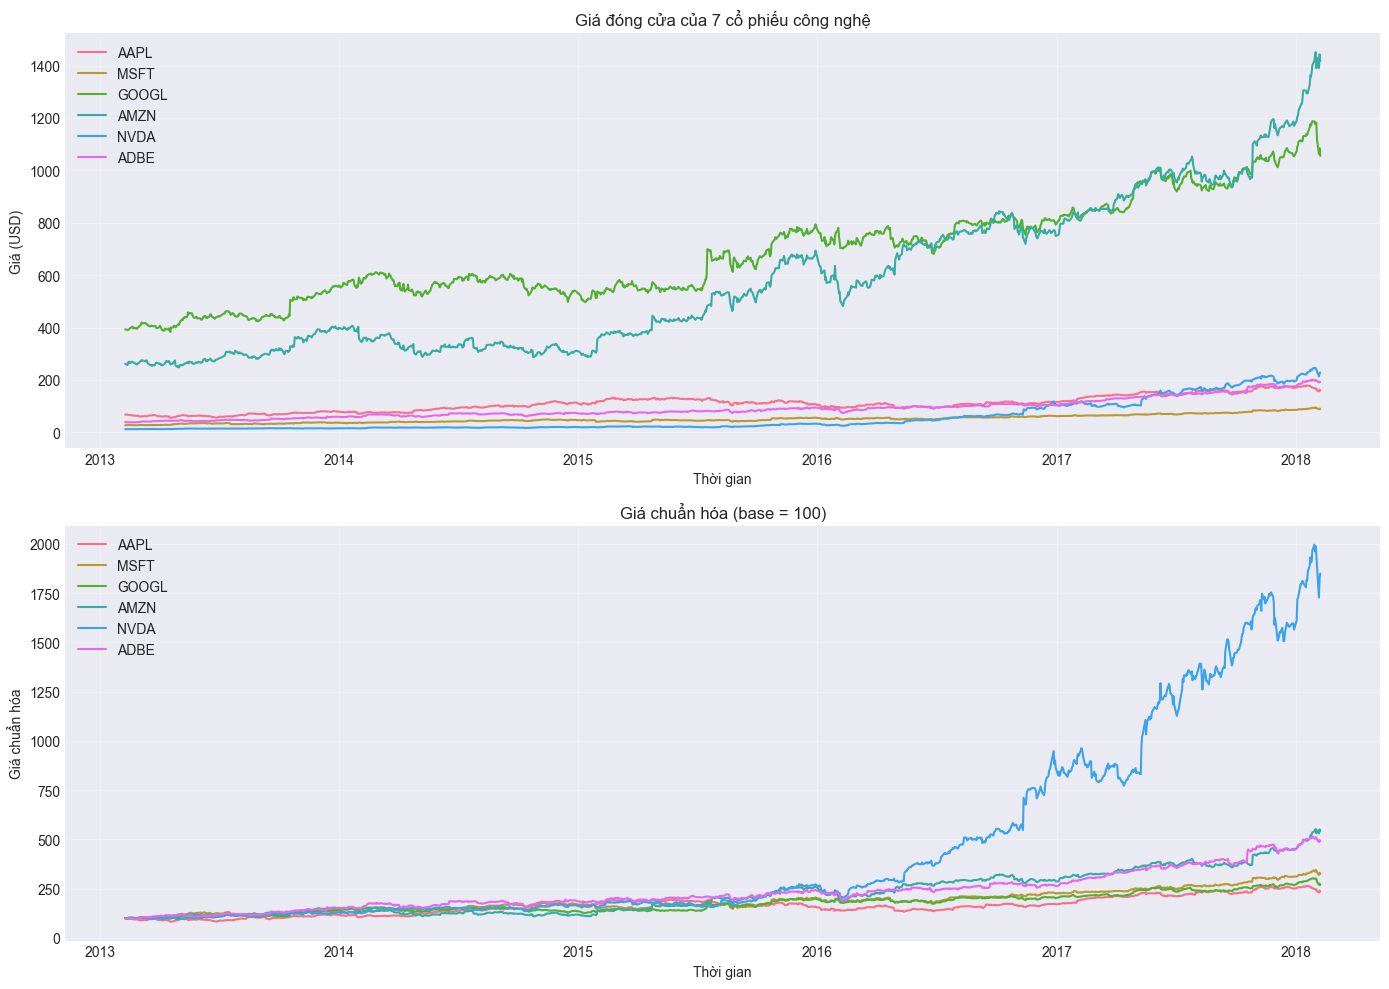

In [5]:
# Chọn 7 cổ phiếu công nghệ
tech_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'ADBE']
# Lưu ý: Trong file csv, cột Name là tên cổ phiếu

# Lọc dữ liệu
tech_data = df[df['Name'].isin(tech_tickers)]

# Pivot table để có giá đóng cửa
prices_df = tech_data.pivot(index='date', columns='Name', values='close')
prices_df = prices_df.sort_index()

print(" GIÁ ĐÓNG CỬA 7 CỔ PHIẾU CÔNG NGHỆ")
print("="*60)
print(f"Số ngày: {len(prices_df)}")
print(f"Từ: {prices_df.index[0]} → {prices_df.index[-1]}")
print("\n5 ngày đầu tiên:")
print(prices_df.head())

# Vẽ biểu đồ giá
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Giá tuyệt đối
ax1 = axes[0]
for ticker in tech_tickers:
    if ticker in prices_df.columns:
        ax1.plot(prices_df.index, prices_df[ticker], label=ticker, linewidth=1.5)

ax1.set_title('Giá đóng cửa của 7 cổ phiếu công nghệ')
ax1.set_xlabel('Thời gian')
ax1.set_ylabel('Giá (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Giá chuẩn hóa (normalized)
ax2 = axes[1]
for ticker in tech_tickers:
    if ticker in prices_df.columns:
        normalized = prices_df[ticker] / prices_df[ticker].iloc[0] * 100
        ax2.plot(prices_df.index, normalized, label=ticker, linewidth=1.5)

ax2.set_title('Giá chuẩn hóa (base = 100)')
ax2.set_xlabel('Thời gian')
ax2.set_ylabel('Giá chuẩn hóa')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 THỐNG KÊ LỢI NHUẬN HÀNG NGÀY
          count   mean    std     min     25%    50%    75%    max  \
Name                                                                 
AAPL  1258.0000 0.0008 0.0146 -0.0799 -0.0064 0.0004 0.0086 0.0820   
ADBE  1258.0000 0.0014 0.0153 -0.0829 -0.0062 0.0011 0.0089 0.1278   
AMZN  1258.0000 0.0015 0.0182 -0.1100 -0.0070 0.0011 0.0108 0.1413   
GOOGL 1258.0000 0.0009 0.0139 -0.0541 -0.0056 0.0006 0.0077 0.1626   
MSFT  1258.0000 0.0010 0.0142 -0.1140 -0.0058 0.0005 0.0078 0.1045   
NVDA  1258.0000 0.0026 0.0224 -0.0927 -0.0075 0.0017 0.0120 0.2981   

       Sharpe (Annualized)  
Name                        
AAPL                0.8552  
ADBE                1.4329  
AMZN                1.3124  
GOOGL               1.0066  
MSFT                1.1605  
NVDA                1.8201  


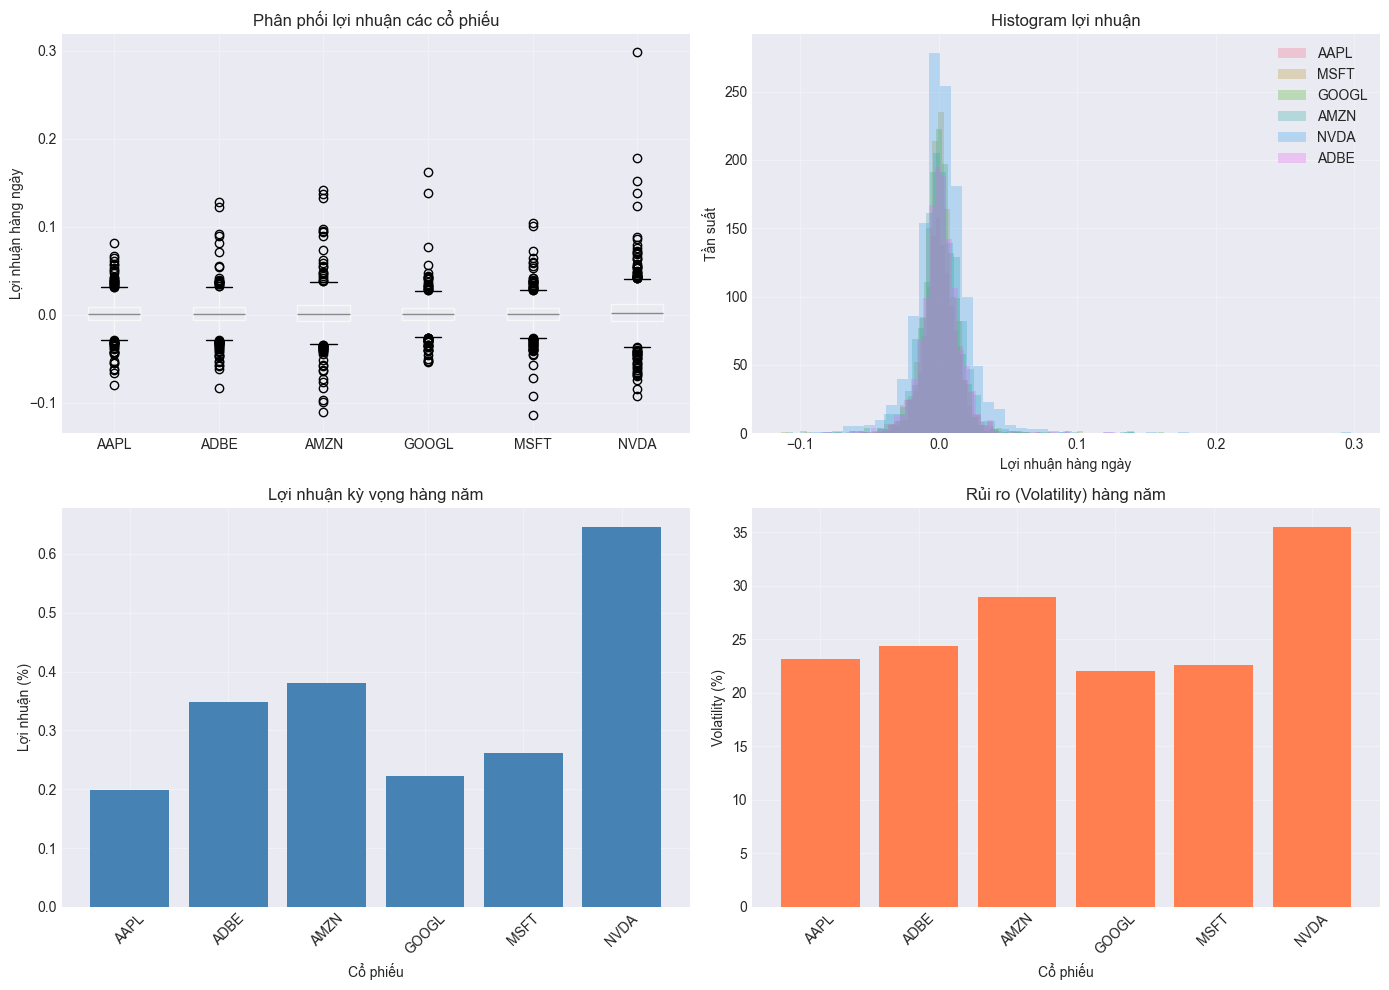

In [6]:
# Tính lợi nhuận hàng ngày
returns_df = prices_df.pct_change().dropna()

# Thống kê cơ bản
stats_df = returns_df.describe().T
stats_df['Sharpe (Annualized)'] = (stats_df['mean'] / stats_df['std']) * np.sqrt(252)

print(" THỐNG KÊ LỢI NHUẬN HÀNG NGÀY")
print("="*60)
print(stats_df.round(4))

# Vẽ phân phối lợi nhuận
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Boxplot
ax1 = axes[0, 0]
returns_df.boxplot(ax=ax1)
ax1.set_title('Phân phối lợi nhuận các cổ phiếu')
ax1.set_ylabel('Lợi nhuận hàng ngày')
ax1.grid(True, alpha=0.3)

# 2. Histogram
ax2 = axes[0, 1]
for ticker in tech_tickers:
    if ticker in returns_df.columns:
        ax2.hist(returns_df[ticker], bins=50, alpha=0.3, label=ticker)
ax2.set_title('Histogram lợi nhuận')
ax2.set_xlabel('Lợi nhuận hàng ngày')
ax2.set_ylabel('Tần suất')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# 3. Mean Return
ax3 = axes[1, 0]
mean_returns = returns_df.mean() * 252  # Annualized
ax3.bar(mean_returns.index, mean_returns.values, color='steelblue')
ax3.set_title('Lợi nhuận kỳ vọng hàng năm')
ax3.set_xlabel('Cổ phiếu')
ax3.set_ylabel('Lợi nhuận (%)')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# 4. Volatility
ax4 = axes[1, 1]
volatility = returns_df.std() * np.sqrt(252)  # Annualized
ax4.bar(volatility.index, volatility.values * 100, color='coral')
ax4.set_title('Rủi ro (Volatility) hàng năm')
ax4.set_xlabel('Cổ phiếu')
ax4.set_ylabel('Volatility (%)')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 MA TRẬN TƯƠNG QUAN
Name    AAPL   ADBE   AMZN  GOOGL   MSFT   NVDA
Name                                           
AAPL  1.0000 0.2919 0.2877 0.3489 0.3666 0.2902
ADBE  0.2919 1.0000 0.3945 0.4284 0.4331 0.3496
AMZN  0.2877 0.3945 1.0000 0.5484 0.4027 0.2581
GOOGL 0.3489 0.4284 0.5484 1.0000 0.4884 0.3066
MSFT  0.3666 0.4331 0.4027 0.4884 1.0000 0.3453
NVDA  0.2902 0.3496 0.2581 0.3066 0.3453 1.0000


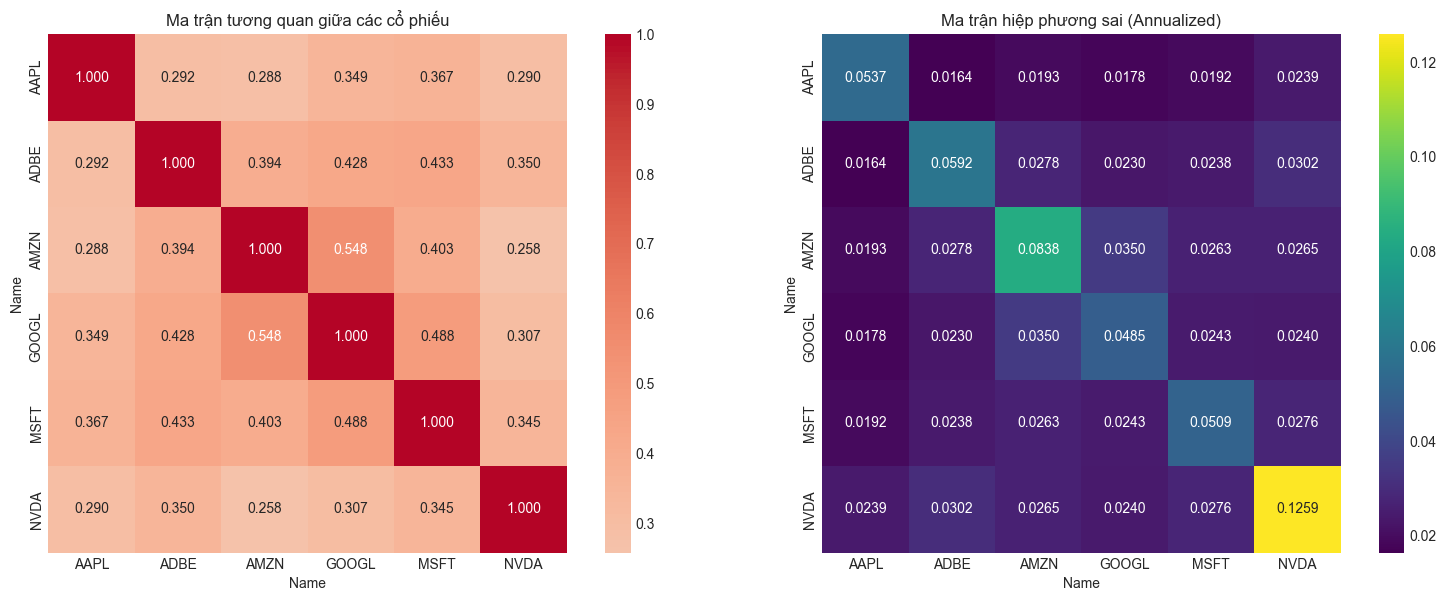

In [8]:
# Ma trận tương quan
correlation_matrix = returns_df.corr()

# Ma trận hiệp phương sai (Annualized)
cov_matrix = returns_df.cov() * 252

print(" MA TRẬN TƯƠNG QUAN")
print("="*60)
print(correlation_matrix.round(4))

# Vẽ heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Correlation Heatmap
ax1 = axes[0]
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            center=0, fmt='.3f', ax=ax1, square=True)
ax1.set_title('Ma trận tương quan giữa các cổ phiếu')

# 2. Covariance Heatmap
ax2 = axes[1]
sns.heatmap(cov_matrix, annot=True, cmap='viridis', 
            fmt='.4f', ax=ax2, square=True)
ax2.set_title('Ma trận hiệp phương sai (Annualized)')

plt.tight_layout()
plt.show()

In [10]:
class PortfolioOptimizer:
    """Lớp tối ưu danh mục đầu tư"""
    
    def __init__(self, expected_returns, cov_matrix, risk_free_rate=0.02):
        self.expected_returns = expected_returns
        self.cov_matrix = cov_matrix
        self.risk_free_rate = risk_free_rate
        self.n_assets = len(expected_returns)
        self.tickers = expected_returns.index.tolist()
        
    def portfolio_performance(self, weights):
        """Tính lợi nhuận, rủi ro và Sharpe Ratio"""
        ret = np.sum(weights * self.expected_returns)
        vol = np.sqrt(weights.T @ self.cov_matrix @ weights)
        sharpe = (ret - self.risk_free_rate) / vol
        return ret, vol, sharpe
    
    def equal_weight(self):
        """Chiến lược phân bổ đều"""
        return np.ones(self.n_assets) / self.n_assets
    
    def minimum_variance(self):
        """Chiến lược phương sai tối thiểu"""
        constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
        bounds = tuple((0, 1) for _ in range(self.n_assets))
        
        def objective(w):
            return w.T @ self.cov_matrix @ w
        
        initial = np.ones(self.n_assets) / self.n_assets
        result = minimize(objective, initial, method='SLSQP',
                         bounds=bounds, constraints=constraints)
        return result.x
    
    def maximum_sharpe(self):
        """Chiến lược Sharpe Ratio tối đa"""
        constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
        bounds = tuple((0, 1) for _ in range(self.n_assets))
        
        def objective(w):
            ret = np.sum(w * self.expected_returns)
            vol = np.sqrt(w.T @ self.cov_matrix @ w)
            return -(ret - self.risk_free_rate) / vol
        
        initial = np.ones(self.n_assets) / self.n_assets
        result = minimize(objective, initial, method='SLSQP',
                         bounds=bounds, constraints=constraints)
        return result.x
    
    def risk_parity(self, max_iter=1000):
        """Chiến lược cân bằng rủi ro"""
        weights = np.ones(self.n_assets) / self.n_assets
        for _ in range(max_iter):
            portfolio_vol = np.sqrt(weights.T @ self.cov_matrix @ weights)
            marginal_risk = self.cov_matrix @ weights / portfolio_vol
            weights = (1 / marginal_risk) / np.sum(1 / marginal_risk)
        return weights
    
    def efficient_frontier(self, n_points=50):
        """Tính Efficient Frontier"""
        target_returns = np.linspace(
            self.expected_returns.min(), 
            self.expected_returns.max(), 
            n_points
        )
        
        frontiers = []
        for target in target_returns:
            constraints = [
                {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
                {'type': 'eq', 'fun': lambda w: np.sum(w * self.expected_returns) - target}
            ]
            bounds = tuple((0, 1) for _ in range(self.n_assets))
            
            def objective(w):
                return w.T @ self.cov_matrix @ w
            
            initial = np.ones(self.n_assets) / self.n_assets
            result = minimize(objective, initial, method='SLSQP',
                             bounds=bounds, constraints=constraints)
            if result.success:
                frontiers.append({
                    'return': target,
                    'volatility': np.sqrt(result.fun),
                    'weights': result.x
                })
        
        return pd.DataFrame(frontiers)
    
    def get_all_strategies(self):
        """Lấy tất cả chiến lược"""
        strategies = {
            'Equal Weight': self.equal_weight(),
            'Minimum Variance': self.minimum_variance(),
            'Maximum Sharpe': self.maximum_sharpe(),
            'Risk Parity': self.risk_parity()
        }
        return strategies

# Khởi tạo optimizer
expected_returns = returns_df.mean() * 252
optimizer = PortfolioOptimizer(expected_returns, cov_matrix, risk_free_rate=0.02)


print(f"Số cổ phiếu: {optimizer.n_assets}")
print(f"Các cổ phiếu: {optimizer.tickers}")

Số cổ phiếu: 6
Các cổ phiếu: ['AAPL', 'ADBE', 'AMZN', 'GOOGL', 'MSFT', 'NVDA']


In [12]:
# Lấy tất cả chiến lược
strategies = optimizer.get_all_strategies()

# Tính toán kết quả
results = {}
for name, weights in strategies.items():
    ret, vol, sharpe = optimizer.portfolio_performance(weights)
    results[name] = {
        'weights': weights,
        'return': ret,
        'volatility': vol,
        'sharpe': sharpe
    }

# Hiển thị kết quả
print("="*80)
print(" KẾT QUẢ TỐI ƯU DANH MỤC")
print("="*80)

# Tạo DataFrame để so sánh
comparison_df = pd.DataFrame()
for name, metrics in results.items():
    comparison_df[name] = pd.Series({
        'Return (%)': metrics['return'] * 100,
        'Volatility (%)': metrics['volatility'] * 100,
        'Sharpe Ratio': metrics['sharpe']
    })

print("\n SO SÁNH CÁC CHỈ SỐ:")
print(comparison_df.round(3))

# Chi tiết trọng số
print("\n TRỌNG SỐ CHI TIẾT:")
for name, metrics in results.items():
    print(f"\n{name}:")
    for ticker, weight in zip(optimizer.tickers, metrics['weights']):
        print(f"  {ticker}: {weight*100:.2f}%")

 KẾT QUẢ TỐI ƯU DANH MỤC

 SO SÁNH CÁC CHỈ SỐ:
                Equal Weight  Minimum Variance  Maximum Sharpe  Risk Parity
Return (%)           34.2650           26.3350         48.1380      32.4030
Volatility (%)       17.8860           16.8790         22.8540      17.4890
Sharpe Ratio          1.8040            1.4420          2.0190       1.7380

 TRỌNG SỐ CHI TIẾT:

Equal Weight:
  AAPL: 16.67%
  ADBE: 16.67%
  AMZN: 16.67%
  GOOGL: 16.67%
  MSFT: 16.67%
  NVDA: 16.67%

Minimum Variance:
  AAPL: 29.06%
  ADBE: 19.08%
  AMZN: 3.12%
  GOOGL: 24.86%
  MSFT: 21.33%
  NVDA: 2.55%

Maximum Sharpe:
  AAPL: 0.00%
  ADBE: 27.34%
  AMZN: 24.29%
  GOOGL: 0.00%
  MSFT: 4.83%
  NVDA: 43.54%

Risk Parity:
  AAPL: 19.70%
  ADBE: 17.18%
  AMZN: 14.53%
  GOOGL: 17.82%
  MSFT: 17.80%
  NVDA: 12.98%


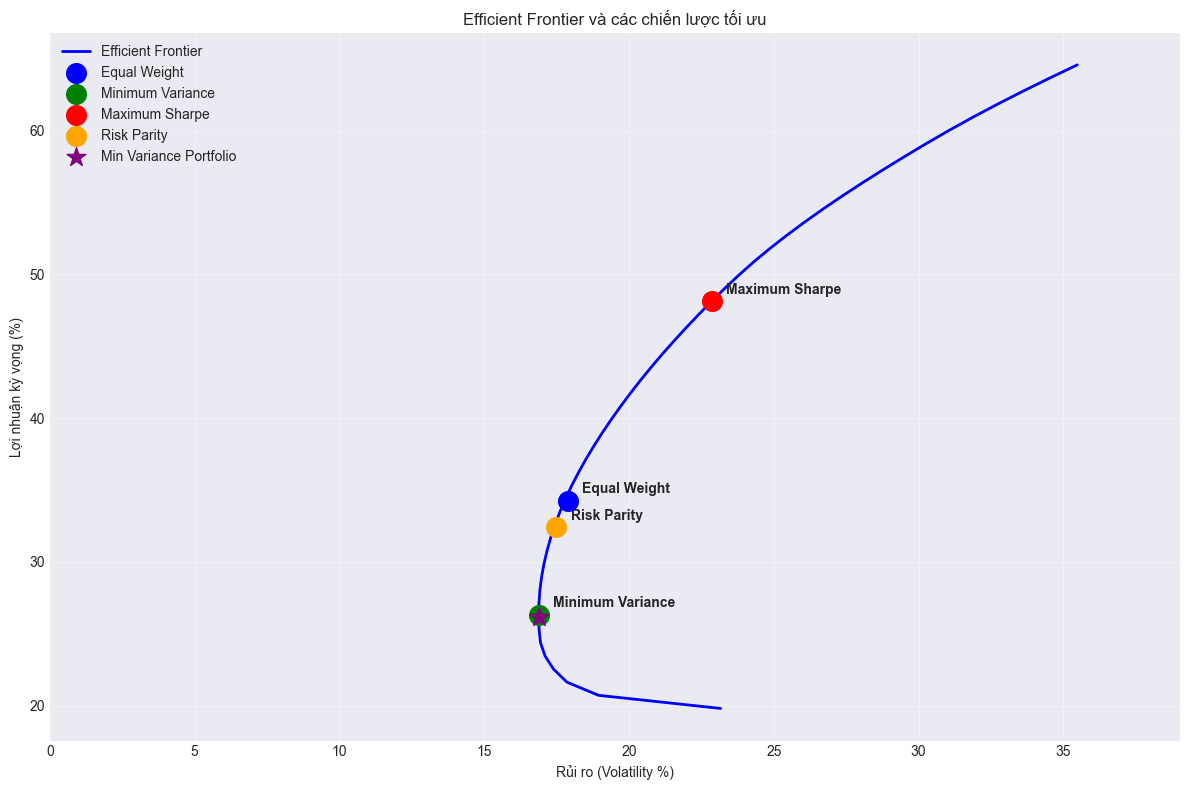

In [13]:
# Tính Efficient Frontier
frontier = optimizer.efficient_frontier(n_points=50)

# Vẽ Efficient Frontier
fig, ax = plt.subplots(figsize=(12, 8))

# Vẽ Efficient Frontier
ax.plot(frontier['volatility'] * 100, frontier['return'] * 100, 
        'b-', linewidth=2, label='Efficient Frontier')

# Đánh dấu các chiến lược
colors = {'Equal Weight': 'blue', 'Minimum Variance': 'green', 
          'Maximum Sharpe': 'red', 'Risk Parity': 'orange'}

for name, metrics in results.items():
    ax.scatter(metrics['volatility'] * 100, metrics['return'] * 100, 
              s=200, color=colors.get(name, 'purple'), 
              label=name, zorder=5)
    ax.annotate(name, (metrics['volatility'] * 100 + 0.5, 
                       metrics['return'] * 100 + 0.5),
                fontsize=10, fontweight='bold')

# Đánh dấu danh mục rủi ro tối thiểu
min_var_idx = frontier['volatility'].idxmin()
ax.scatter(frontier.loc[min_var_idx, 'volatility'] * 100,
           frontier.loc[min_var_idx, 'return'] * 100,
           s=200, color='purple', marker='*', 
           label='Min Variance Portfolio', zorder=6)

ax.set_xlabel('Rủi ro (Volatility %)')
ax.set_ylabel('Lợi nhuận kỳ vọng (%)')
ax.set_title('Efficient Frontier và các chiến lược tối ưu')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, frontier['volatility'].max() * 100 * 1.1)

plt.tight_layout()
plt.show()

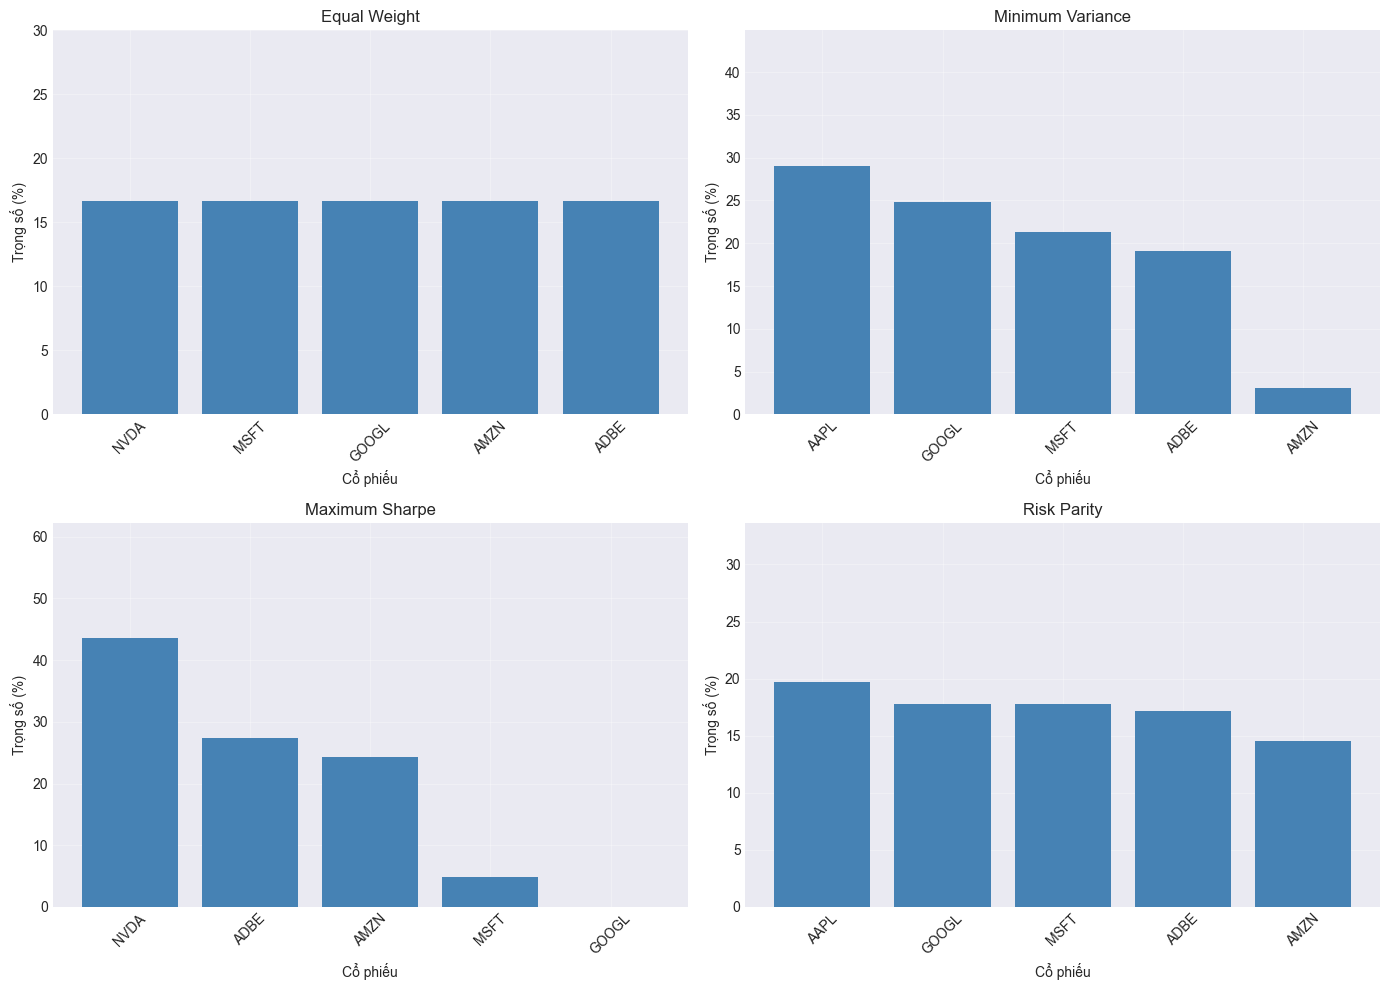

In [14]:
# Vẽ biểu đồ trọng số cho từng chiến lược
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, metrics) in enumerate(results.items()):
    ax = axes[idx]
    weights = metrics['weights']
    
    # Sắp xếp theo trọng số giảm dần
    sorted_idx = np.argsort(weights)[::-1]
    sorted_weights = weights[sorted_idx]
    sorted_tickers = np.array(optimizer.tickers)[sorted_idx]
    
    # Chỉ hiển thị top 5
    top_5 = sorted_weights[:5]
    top_5_tickers = sorted_tickers[:5]
    
    ax.bar(top_5_tickers, top_5 * 100, color='steelblue')
    ax.set_title(f'{name}')
    ax.set_xlabel('Cổ phiếu')
    ax.set_ylabel('Trọng số (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, max(weights) * 100 * 1.2 + 10)

plt.tight_layout()
plt.show()

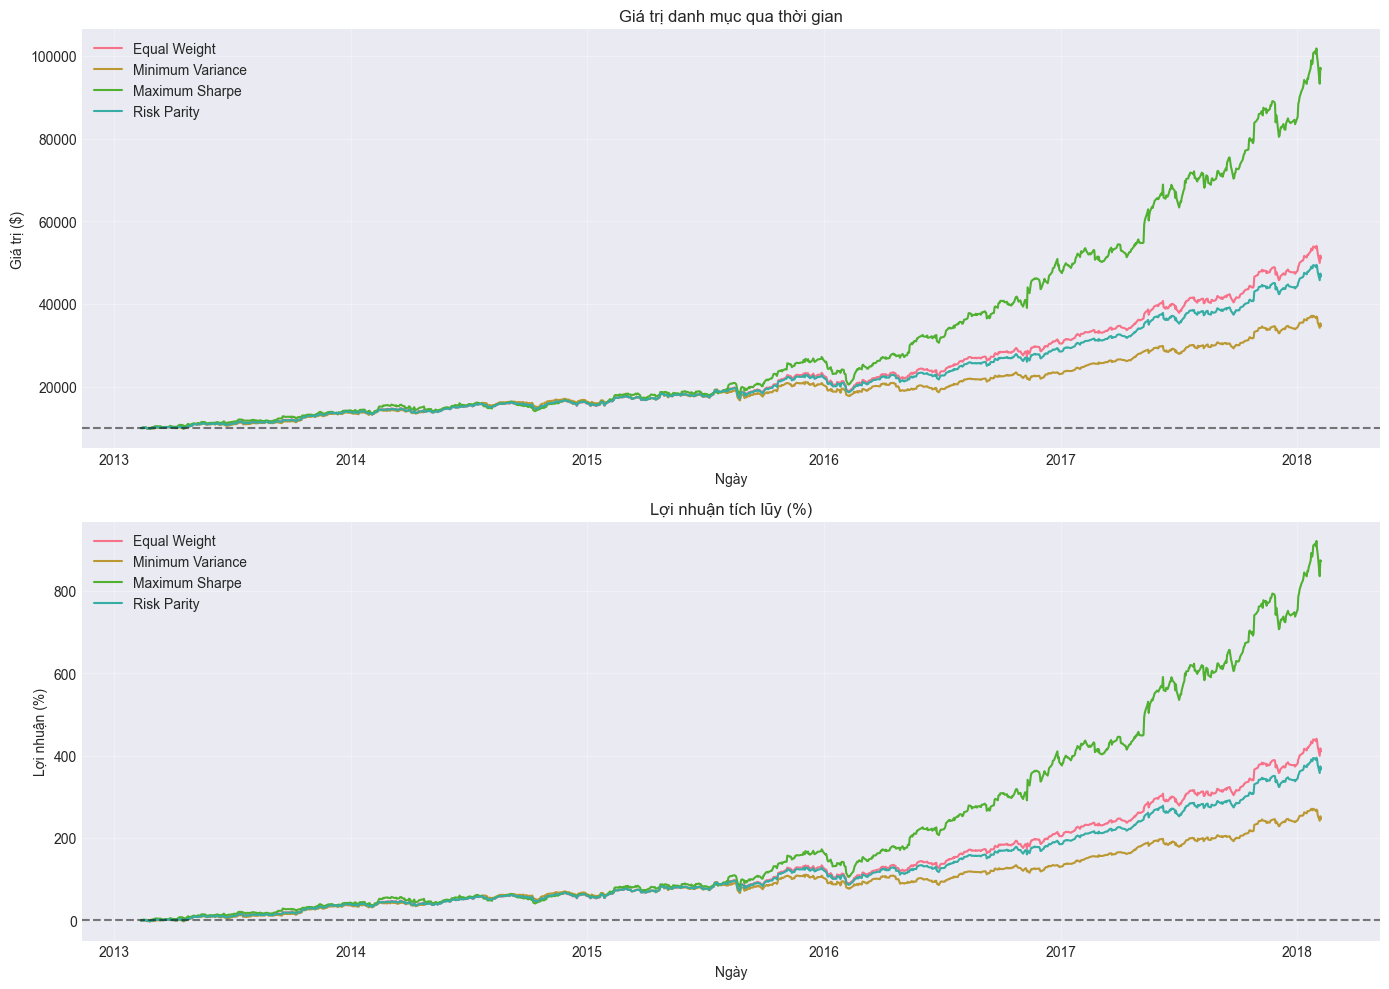

In [15]:
def backtest_portfolio(returns_df, weights, initial_capital=10000):
    """Backtest chiến lược danh mục"""
    portfolio_returns = returns_df @ weights
    portfolio_values = initial_capital * (1 + portfolio_returns).cumprod()
    return portfolio_values, portfolio_returns

# Chạy backtest cho từng chiến lược
backtest_results = {}
for name, metrics in results.items():
    values, rets = backtest_portfolio(returns_df, metrics['weights'])
    backtest_results[name] = {
        'values': values,
        'returns': rets
    }

# Vẽ kết quả backtest
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Giá trị danh mục
ax1 = axes[0]
for name, data in backtest_results.items():
    ax1.plot(data['values'], label=name, linewidth=1.5)

ax1.axhline(y=10000, color='black', linestyle='--', alpha=0.5)
ax1.set_title('Giá trị danh mục qua thời gian')
ax1.set_xlabel('Ngày')
ax1.set_ylabel('Giá trị ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Lợi nhuận tích lũy (%)
ax2 = axes[1]
for name, data in backtest_results.items():
    cumulative_return = (data['values'] / data['values'].iloc[0] - 1) * 100
    ax2.plot(cumulative_return, label=name, linewidth=1.5)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_title('Lợi nhuận tích lũy (%)')
ax2.set_xlabel('Ngày')
ax2.set_ylabel('Lợi nhuận (%)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
def calculate_advanced_metrics(returns, risk_free_rate=0.02):
    """Tính các chỉ số đánh giá nâng cao"""
    # Lợi nhuận hàng năm
    annual_return = returns.mean() * 252
    
    # Volatility hàng năm
    annual_vol = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio
    sharpe = (annual_return - risk_free_rate) / annual_vol if annual_vol > 0 else 0
    
    # Sortino Ratio (chỉ xét rủi ro giảm)
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 0 else 1
    sortino = (annual_return - risk_free_rate) / downside_vol if downside_vol > 0 else 0
    
    # Maximum Drawdown
    cum_returns = (1 + returns).cumprod()
    rolling_max = cum_returns.expanding().max()
    drawdown = (rolling_max - cum_returns) / rolling_max
    max_drawdown = drawdown.max()
    
    # Calmar Ratio (Annual Return / Max Drawdown)
    calmar = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Win Rate
    win_rate = (returns > 0).mean()
    
    return {
        'Annual Return (%)': annual_return * 100,
        'Volatility (%)': annual_vol * 100,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown (%)': max_drawdown * 100,
        'Calmar Ratio': calmar,
        'Win Rate (%)': win_rate * 100
    }

# Tính metrics cho từng chiến lược
metrics_df = pd.DataFrame()
for name, data in backtest_results.items():
    metrics = calculate_advanced_metrics(data['returns'])
    metrics_df[name] = pd.Series(metrics)

print(" BẢNG SO SÁNH CHỈ SỐ ĐÁNH GIÁ")
print("="*80)
print(metrics_df.round(2))

 BẢNG SO SÁNH CHỈ SỐ ĐÁNH GIÁ
                   Equal Weight  Minimum Variance  Maximum Sharpe  Risk Parity
Annual Return (%)       34.2600           26.3400         48.1400      32.4000
Volatility (%)          17.8900           16.8800         22.8500      17.4900
Sharpe Ratio             1.8000            1.4400          2.0200       1.7400
Sortino Ratio            2.4700            1.9700          2.9500       2.3700
Max Drawdown (%)        19.1100           16.1600         24.5900      18.5400
Calmar Ratio             1.7900            1.6300          1.9600       1.7500
Win Rate (%)            56.7600           56.5200         57.2300      56.5200


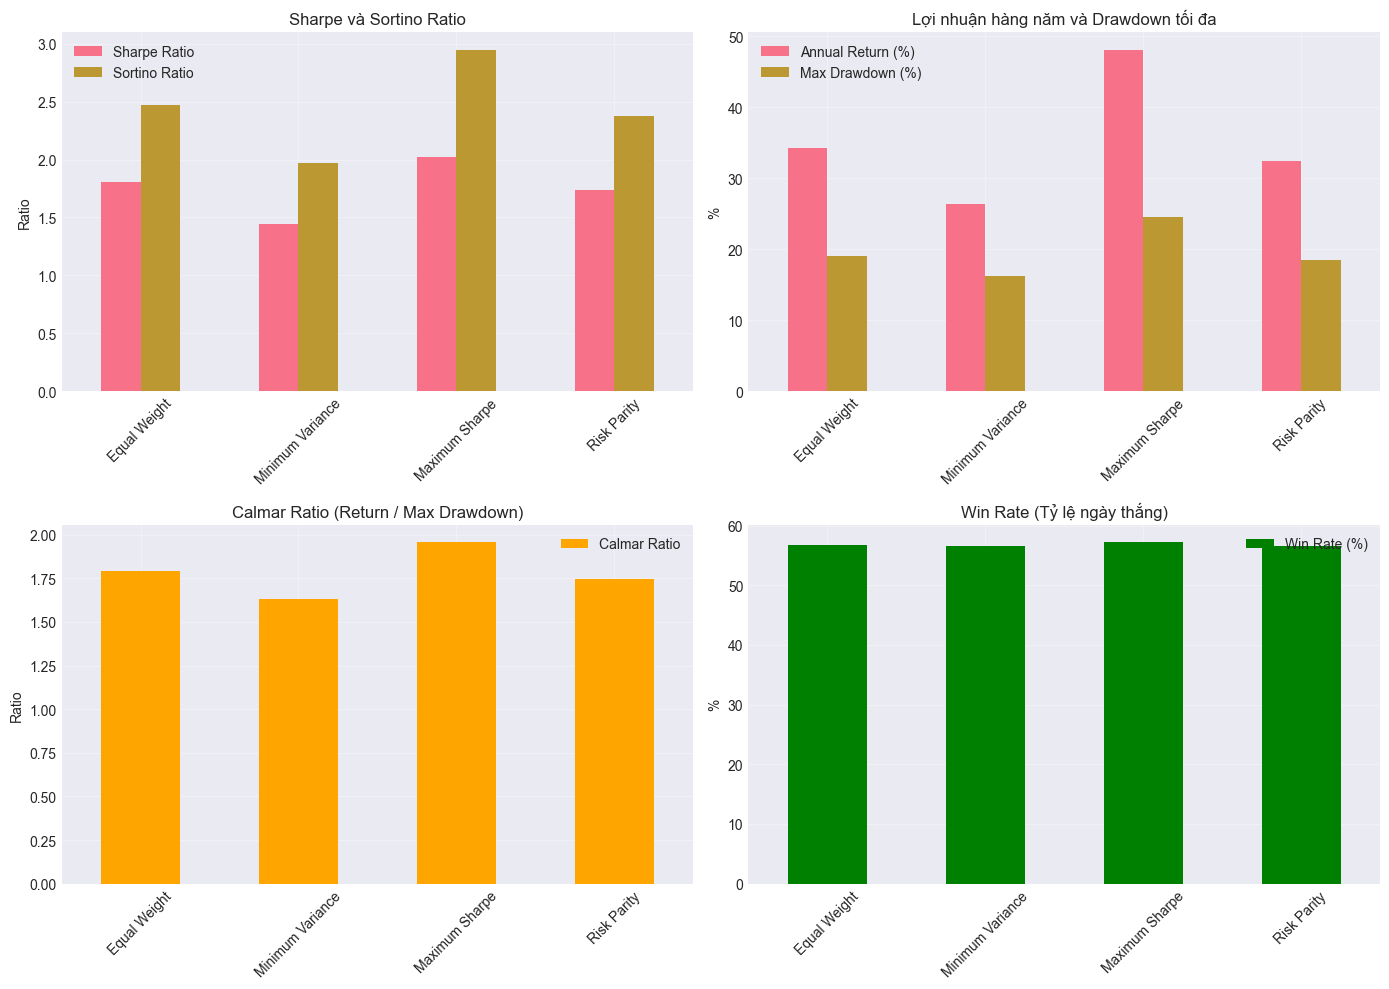

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sharpe & Sortino Ratio
ax1 = axes[0, 0]
metrics_df.loc[['Sharpe Ratio', 'Sortino Ratio']].T.plot(kind='bar', ax=ax1)
ax1.set_title('Sharpe và Sortino Ratio')
ax1.set_ylabel('Ratio')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Return vs Max Drawdown
ax2 = axes[0, 1]
metrics_df.loc[['Annual Return (%)', 'Max Drawdown (%)']].T.plot(kind='bar', ax=ax2)
ax2.set_title('Lợi nhuận hàng năm và Drawdown tối đa')
ax2.set_ylabel('%')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Calmar Ratio
ax3 = axes[1, 0]
metrics_df.loc[['Calmar Ratio']].T.plot(kind='bar', ax=ax3, color='orange')
ax3.set_title('Calmar Ratio (Return / Max Drawdown)')
ax3.set_ylabel('Ratio')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. Win Rate
ax4 = axes[1, 1]
metrics_df.loc[['Win Rate (%)']].T.plot(kind='bar', ax=ax4, color='green')
ax4.set_title('Win Rate (Tỷ lệ ngày thắng)')
ax4.set_ylabel('%')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

 SO SÁNH VỚI BUY & HOLD
                   Buy & Hold  Maximum Sharpe
Annual Return (%)     34.2600         48.1400
Volatility (%)        17.8900         22.8500
Sharpe Ratio           1.8000          2.0200
Sortino Ratio          2.4700          2.9500
Max Drawdown (%)      19.1100         24.5900
Calmar Ratio           1.7900          1.9600
Win Rate (%)          56.7600         57.2300


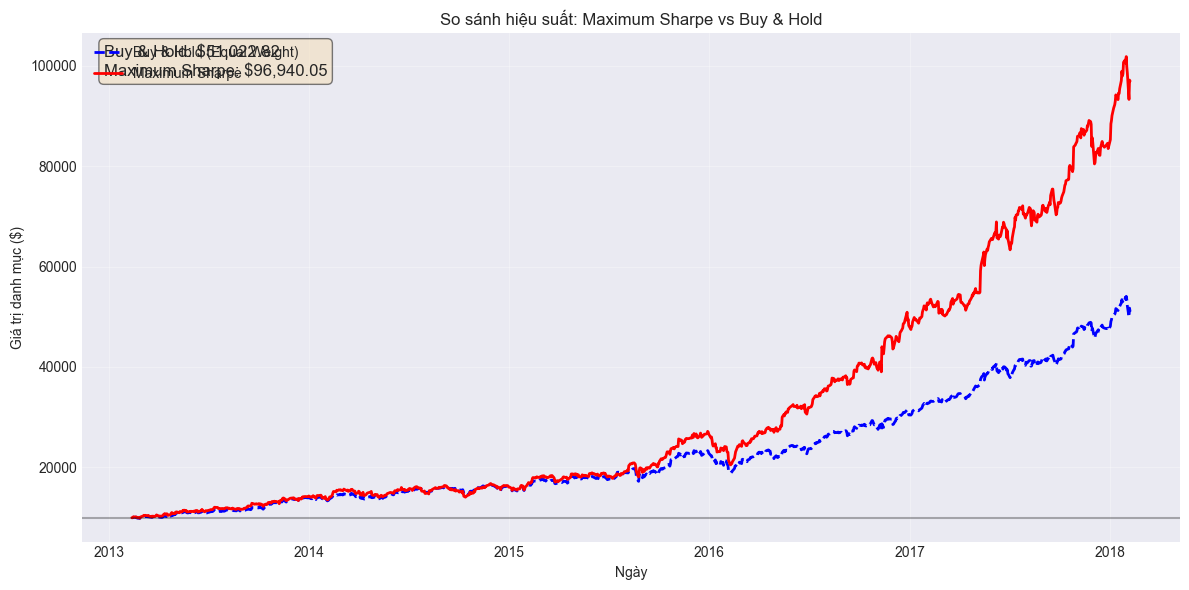

In [18]:
# Tạo danh mục Buy & Hold (giả định S&P 500)
# Sử dụng Equal Weight làm baseline
buy_hold_weights = np.ones(len(optimizer.tickers)) / len(optimizer.tickers)

# Tính returns cho Buy & Hold
buy_hold_returns = returns_df @ buy_hold_weights
buy_hold_values = 10000 * (1 + buy_hold_returns).cumprod()
buy_hold_metrics = calculate_advanced_metrics(buy_hold_returns)

# So sánh với chiến lược tốt nhất (Maximum Sharpe)
best_strategy = 'Maximum Sharpe'
best_values = backtest_results[best_strategy]['values']
best_metrics = calculate_advanced_metrics(backtest_results[best_strategy]['returns'])

print("="*80)
print(" SO SÁNH VỚI BUY & HOLD")
print("="*80)

comparison = pd.DataFrame({
    'Buy & Hold': buy_hold_metrics,
    best_strategy: best_metrics
})
print(comparison.round(2))

# Vẽ biểu đồ so sánh
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(buy_hold_values, label='Buy & Hold (Equal Weight)', 
        color='blue', linestyle='--', linewidth=2)
ax.plot(best_values, label=f'{best_strategy}', 
        color='red', linewidth=2)
ax.axhline(y=10000, color='black', linestyle='-', alpha=0.3)

ax.set_title(f'So sánh hiệu suất: {best_strategy} vs Buy & Hold')
ax.set_xlabel('Ngày')
ax.set_ylabel('Giá trị danh mục ($)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Thêm thông tin
final_bh = buy_hold_values.iloc[-1]
final_strategy = best_values.iloc[-1]
textstr = f'Buy & Hold: ${final_bh:,.2f}\n{best_strategy}: ${final_strategy:,.2f}'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

 PHÂN TÍCH RỦI RO DANH MỤC (Maximum Sharpe)
      Ticker  Weight (%)  Risk Contribution (%)
Name                                           
NVDA    NVDA     43.5400                59.0400
ADBE    ADBE     27.3400                19.4700
AMZN    AMZN     24.2900                18.9600
MSFT    MSFT      4.8300                 2.5300
GOOGL  GOOGL      0.0000                 0.0000
AAPL    AAPL      0.0000                 0.0000


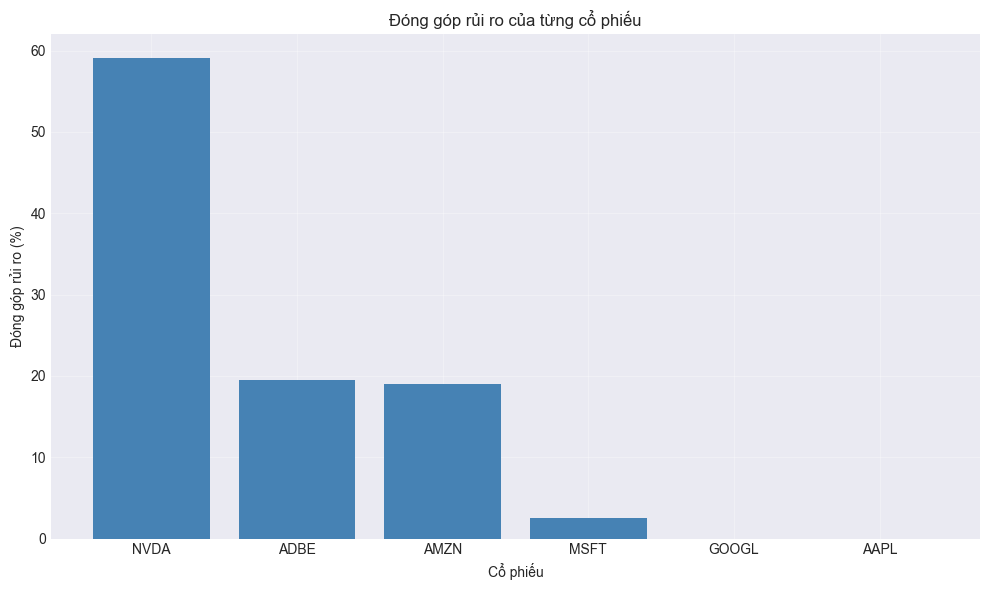

In [19]:
# Phân tích rủi ro cho chiến lược Maximum Sharpe
best_weights = results['Maximum Sharpe']['weights']

# Đóng góp rủi ro của từng cổ phiếu
portfolio_vol = np.sqrt(best_weights.T @ cov_matrix @ best_weights)
marginal_risk = cov_matrix @ best_weights / portfolio_vol
risk_contribution = best_weights * marginal_risk

print(" PHÂN TÍCH RỦI RO DANH MỤC (Maximum Sharpe)")
print("="*80)

risk_df = pd.DataFrame({
    'Ticker': optimizer.tickers,
    'Weight (%)': best_weights * 100,
    'Risk Contribution (%)': risk_contribution / portfolio_vol * 100
})
risk_df = risk_df.sort_values('Risk Contribution (%)', ascending=False)
print(risk_df.round(2))

# Vẽ biểu đồ đóng góp rủi ro
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(risk_df['Ticker'], risk_df['Risk Contribution (%)'], 
       color='steelblue')
ax.set_title('Đóng góp rủi ro của từng cổ phiếu')
ax.set_xlabel('Cổ phiếu')
ax.set_ylabel('Đóng góp rủi ro (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Lưu báo cáo
report = {
    'Comparison DataFrame': comparison_df,
    'Metrics DataFrame': metrics_df,
    'Risk Analysis': risk_df,
    'Best Strategy': best_strategy,
    'Optimal Weights': results['Maximum Sharpe']['weights']
}

# Lưu vào Excel
with pd.ExcelWriter('portfolio_optimization_report.xlsx') as writer:
    comparison_df.to_excel(writer, sheet_name='Comparison')
    metrics_df.to_excel(writer, sheet_name='Metrics')
    risk_df.to_excel(writer, sheet_name='Risk_Analysis')
    pd.DataFrame({
        'Ticker': optimizer.tickers,
        'Optimal_Weights': results['Maximum Sharpe']['weights']
    }).to_excel(writer, sheet_name='Optimal_Weights', index=False)

print(" Đã lưu báo cáo vào 'portfolio_optimization_report.xlsx'")
print("\n KẾT LUẬN:")
print("="*80)
print(f"Chiến lược tốt nhất: {best_strategy}")
print(f"Sharpe Ratio: {best_metrics['Sharpe Ratio']:.3f}")
print(f"Lợi nhuận hàng năm: {best_metrics['Annual Return (%)']:.2f}%")
print(f"Rủi ro: {best_metrics['Volatility (%)']:.2f}%")
print(f"Drawdown tối đa: {best_metrics['Max Drawdown (%)']:.2f}%")
print("="*80)

 Đã lưu báo cáo vào 'portfolio_optimization_report.xlsx'

 KẾT LUẬN:
Chiến lược tốt nhất: Maximum Sharpe
Sharpe Ratio: 2.019
Lợi nhuận hàng năm: 48.14%
Rủi ro: 22.85%
Drawdown tối đa: 24.59%


In [21]:
print("="*80)
print(" TỔNG KẾT PHÂN TÍCH")
print("="*80)

print("\n1️ PHÂN TÍCH TƯƠNG QUAN:")
high_corr = correlation_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1].head(3)
print("Các cặp cổ phiếu tương quan cao nhất:")
for pair, corr in high_corr.items():
    print(f"  {pair[0]} - {pair[1]}: {corr:.3f}")

print("\n2️ CHIẾN LƯỢC TỐI ƯU:")
print(f"- {best_strategy} là chiến lược tốt nhất với Sharpe Ratio = {best_metrics['Sharpe Ratio']:.3f}")
print(f"- Lợi nhuận hàng năm: {best_metrics['Annual Return (%)']:.2f}%")
print(f"- Rủi ro: {best_metrics['Volatility (%)']:.2f}%")

print("\n3️ PHÂN BỔ KHUYẾN NGHỊ:")
print("Dựa trên chiến lược Maximum Sharpe:")
for ticker, weight in zip(optimizer.tickers, results['Maximum Sharpe']['weights']):
    if weight > 0.05:
        print(f"  - {ticker}: {weight*100:.2f}%")

print("\n4️ RỦI RO:")
print(f"- Drawdown tối đa: {best_metrics['Max Drawdown (%)']:.2f}%")
print(f"- Calmar Ratio: {best_metrics['Calmar Ratio']:.3f}")

print("\n LƯU Ý:")
print("- Đây là phân tích dựa trên dữ liệu quá khứ, không đảm bảo hiệu suất tương lai")
print("- Nên tái cân bằng danh mục định kỳ (hàng tháng/quý)")
print("- Cân nhắc thêm các tài sản khác để đa dạng hóa rủi ro")
print("="*80)

 TỔNG KẾT PHÂN TÍCH

1️ PHÂN TÍCH TƯƠNG QUAN:
Các cặp cổ phiếu tương quan cao nhất:
  AMZN - GOOGL: 0.548
  GOOGL - AMZN: 0.548
  MSFT - GOOGL: 0.488

2️ CHIẾN LƯỢC TỐI ƯU:
- Maximum Sharpe là chiến lược tốt nhất với Sharpe Ratio = 2.019
- Lợi nhuận hàng năm: 48.14%
- Rủi ro: 22.85%

3️ PHÂN BỔ KHUYẾN NGHỊ:
Dựa trên chiến lược Maximum Sharpe:
  - ADBE: 27.34%
  - AMZN: 24.29%
  - NVDA: 43.54%

4️ RỦI RO:
- Drawdown tối đa: 24.59%
- Calmar Ratio: 1.958

 LƯU Ý:
- Đây là phân tích dựa trên dữ liệu quá khứ, không đảm bảo hiệu suất tương lai
- Nên tái cân bằng danh mục định kỳ (hàng tháng/quý)
- Cân nhắc thêm các tài sản khác để đa dạng hóa rủi ro
